In [1]:
library(tidyverse)
library(cowplot)

stage_colors <- c(immature = "#93C572", mature = "#3F7A43")
outline      <- "grey25"

theme_set(theme_cowplot(font_size = 12))
options(repr.plot.width = 8, repr.plot.height = 4.5)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘cowplot’




The following object is masked from ‘package:lubridate’:

    stamp




In [2]:
glands <- read_csv("data/gland_positions.csv", show_col_types = FALSE)

glands$stage <- factor(glands$stage, levels = c("immature", "mature"))

glands

stage,image,x_um,y_um
<fct>,<chr>,<dbl>,<dbl>
immature,istb50x,213.682,447.522
immature,istb50x,511.778,148.922
immature,istb50x,548.064,693.206
immature,istb50x,1023.808,257.779
immature,istb50x,1156.856,540.000
immature,istb50x,773.841,991.555
immature,istb50x,1172.983,1241.522
immature,istb50x,644.825,1551.965
immature,istb50x,306.160,1152.824


In [3]:
glands %>%
  group_by(image) %>%
  mutate(nearest_um = sapply(1:n(), function(i) {
    d <- sqrt((x_um - x_um[i])^2 + (y_um - y_um[i])^2)
    min(d[-i])
  })) %>%
  ungroup() -> glands

glands

stage,image,x_um,y_um,nearest_um
<fct>,<chr>,<dbl>,<dbl>,<dbl>
immature,istb50x,213.682,447.522,414.9361
immature,istb50x,511.778,148.922,421.9279
immature,istb50x,548.064,693.206,374.1489
immature,istb50x,1023.808,257.779,312.0104
immature,istb50x,1156.856,540.000,312.0104
immature,istb50x,773.841,991.555,374.1489
immature,istb50x,1172.983,1241.522,361.5543
immature,istb50x,644.825,1551.965,376.8759
immature,istb50x,306.160,1152.824,272.5529


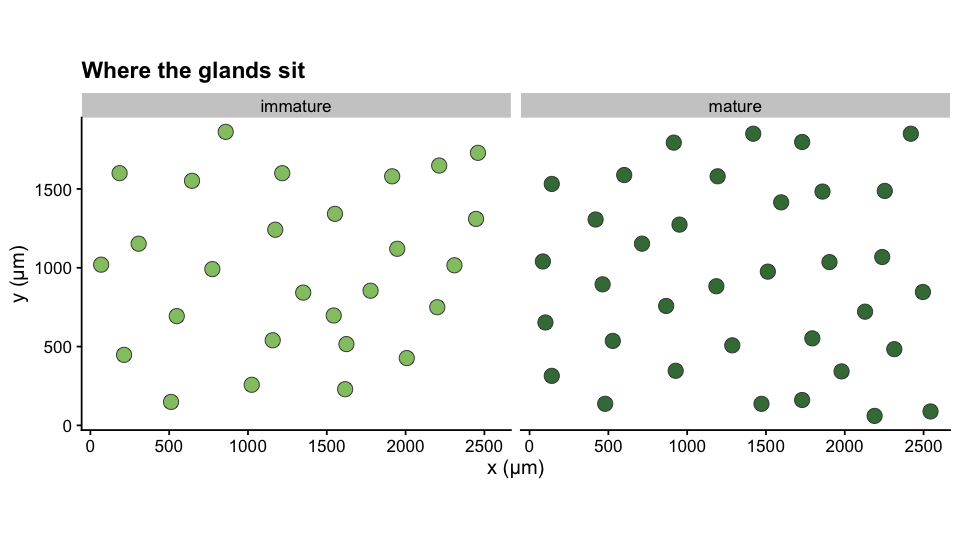

In [4]:
plot1 <- ggplot(glands, aes(x = x_um, y = y_um, fill = stage)) +
  geom_point(shape = 21, size = 4, stroke = 0.4, colour = outline) +
  scale_fill_manual(values = stage_colors) +
  coord_fixed() +
  facet_wrap(~ stage) +
  labs(title = "Where the glands sit", x = "x (µm)", y = "y (µm)") +
  theme(legend.position = "none")

plot1
ggsave("output/gland_map.png", plot1, width = 9, height = 4.5, dpi = 300)

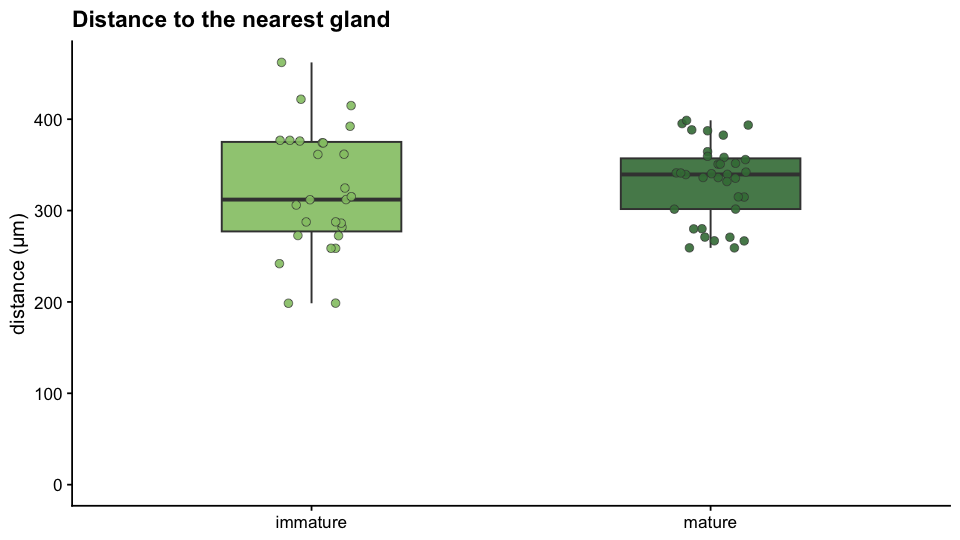

In [5]:
plot2 <- ggplot(glands, aes(x = stage, y = nearest_um, fill = stage)) +
  geom_boxplot(width = 0.45, outlier.shape = NA, alpha = 0.9, colour = outline) +
  geom_jitter(shape = 21, width = 0.10, size = 2.2, stroke = 0.3,
              colour = outline, alpha = 0.9) +
  scale_fill_manual(values = stage_colors) +
  scale_y_continuous(limits = c(0, NA)) +
  labs(title = "Distance to the nearest gland", x = NULL, y = "distance (µm)") +
  theme(legend.position = "none")

plot2
ggsave("output/gland_spacing.png", plot2, width = 6, height = 4.5, dpi = 300)

In [6]:
field_um2 <- 2560 * 1920
field_mm2 <- field_um2 / 1e6
perimeter <- 2 * (2560 + 1920)

glands %>%
  group_by(stage) %>%
  summarise(
    glands      = n(),
    density     = n() / field_mm2,
    mean_gap    = mean(nearest_um),
    sd_gap      = sd(nearest_um),
    cv_gap      = sd(nearest_um) / mean(nearest_um),
    expected    = 0.5 * sqrt(field_um2 / n()) +
                  0.0514 * perimeter / n() +
                  0.041  * perimeter / n()^1.5,
    clark_evans = mean_gap / expected
  ) -> summary_table

as.data.frame(summary_table)

stage,glands,density,mean_gap,sd_gap,cv_gap,expected,clark_evans
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
immature,27,5.493164,322.5027,66.86598,0.2073346,233.0090,1.384078
mature,35,7.120768,331.6476,42.03433,0.1267440,202.3054,1.639342
